In [ ]:
#importing the data 

In [1]:
!pip install pandas 
!pip install yfinance

In [2]:
import pandas as pd 
import yfinance as yf

In [27]:
nifty = yf.download("^NSEI", start="2007-09-17", end="2026-01-01", auto_adjust=True)
oil = yf.download("BZ=F", start="2007-09-17", end="2026-01-01", auto_adjust=True)

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,BZ=F,BZ=F,BZ=F,BZ=F,BZ=F
Date,,,,,
2007-09-17,76.980003,77.040001,75.540001,75.540001,2573
2007-09-18,77.589996,78.330002,76.330002,76.669998,3427
2007-09-19,78.470001,78.559998,77.459999,78.040001,3109
2007-09-20,79.089996,79.269997,77.820000,77.870003,2426
2007-09-21,79.300003,79.949997,78.480003,79.250000,2768
...,...,...,...,...,...
2025-12-24,62.240002,62.720001,62.020000,62.430000,14966
2025-12-26,60.639999,62.689999,60.590000,62.349998,9687


In [30]:
df1= pd.DataFrame(nifty)
df2=pd.DataFrame(oil)

In [32]:
# 1. Create a new "Master" DataFrame
df = pd.DataFrame()

# 2. Extract only the 'Close' column from your downloads
df['Nifty50'] = nifty['Close']
df['Crude_Oil'] = crudeoil['Close']

# 3. Align the dates (Drop rows where one market was closed)
df = df.dropna()

# 4. Calculate the % Change (This answers your "why change in price" question!)
df['Nifty_Pct'] = df['Nifty50'].pct_change()
df['Crude_Pct'] = df['Crude_Oil'].pct_change()

# 5. Remove the first row (which will be NaN after calculating % change)
df = df.dropna()

# 6. Show the final clean data
print(df.head())

                Nifty50  Crude_Oil  Nifty_Pct  Crude_Pct
Date                                                    
2007-09-18  4546.200195  81.510002   0.011469   0.011667
2007-09-19  4732.350098  81.930000   0.040946   0.005153
2007-09-20  4747.549805  83.320000   0.003212   0.016966
2007-09-21  4837.549805  81.620003   0.018957  -0.020403
2007-09-24  4932.200195  80.949997   0.019566  -0.008209


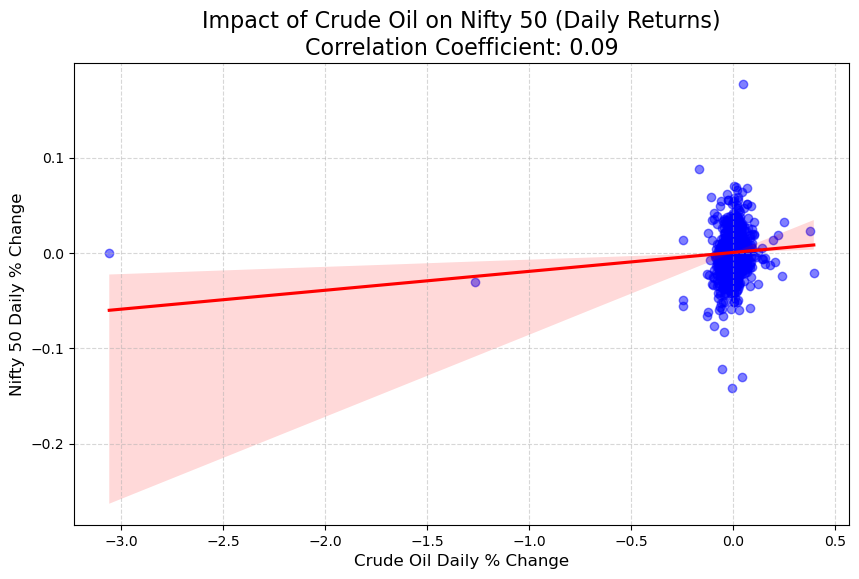

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Set the size of the graph
plt.figure(figsize=(10, 6))

# 2. Create the Scatter Plot with a Regression Line
# x = Oil (The Cause), y = Nifty (The Effect)
sns.regplot(x='Crude_Pct', y='Nifty_Pct', data=df, 
            scatter_kws={'alpha':0.5, 'color':'blue'}, # Makes dots semi-transparent
            line_kws={'color':'red'}) # Makes the trendline red

# 3. Calculate the Correlation Score
corr = df['Crude_Pct'].corr(df['Nifty_Pct'])

# 4. Add Labels and Title
plt.title(f'Impact of Crude Oil on Nifty 50 (Daily Returns)\nCorrelation Coefficient: {corr:.2f}', fontsize=16)
plt.xlabel('Crude Oil Daily % Change', fontsize=12)
plt.ylabel('Nifty 50 Daily % Change', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)

# 5. Show it!
plt.show()

In [35]:
# 1. Filter out extreme outliers (e.g., drops greater than 50% in a single day)
# This removes the "Negative Oil Price" day which skews the math.
df_clean = df[df['Crude_Pct'] > -0.5] 

# 2. Let's see the NEW correlation without that one crazy day
new_corr = df_clean['Crude_Pct'].corr(df_clean['Nifty_Pct'])
print(f"New Correlation Coefficient: {new_corr}")

New Correlation Coefficient: 0.14971620609253924


C:\Users\saran\AppData\Local\Temp\ipykernel_15472\74090768.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['Rolling_Corr'] = df_clean['Crude_Pct'].rolling(window=90).corr(df_clean['Nifty_Pct'])


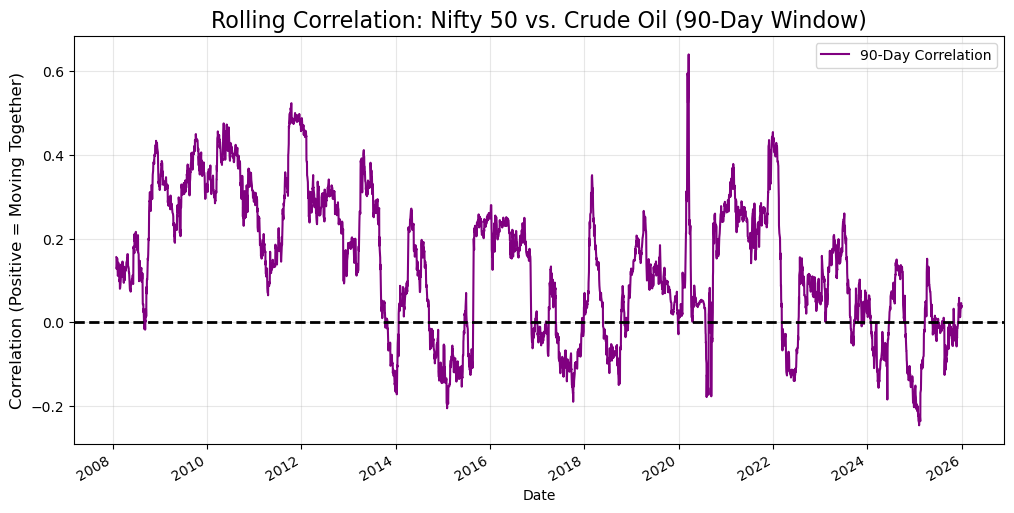

In [36]:
# 1. Calculate a 90-day Rolling Correlation
# This asks: "Over the last 3 months, were they friends or enemies?"
df_clean['Rolling_Corr'] = df_clean['Crude_Pct'].rolling(window=90).corr(df_clean['Nifty_Pct'])

# 2. Create the Plot
plt.figure(figsize=(12, 6))

# Plot the rolling correlation
df_clean['Rolling_Corr'].plot(color='purple', label='90-Day Correlation')

# Add a "Zero Line" - Above this is Positive, Below is Negative
plt.axhline(y=0, color='black', linestyle='--', linewidth=2)

# Add title and labels
plt.title('Rolling Correlation: Nifty 50 vs. Crude Oil (90-Day Window)', fontsize=16)
plt.ylabel('Correlation (Positive = Moving Together)', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

In [37]:

# We use index=True to keep the 'Date' column
df_clean.to_csv('Nifty_vs_Oil_Analysis.csv', index=True)

print("File saved successfully! Check your folder for 'Nifty_vs_Oil_Analysis.csv'")

File saved successfully! Check your folder for 'Nifty_vs_Oil_Analysis.csv'


In [38]:
import os
print(os.getcwd())

C:\Users\saran\Macro-economic
